In [1]:
%matplotlib inline
import time
import pandas as pd
import numpy as np
import sys
import os
import pathlib
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms import VQE
import numpy as np


notebook_dir = pathlib.Path().resolve()
parent_dir = notebook_dir.parent
sys.path.append(str(parent_dir))

from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

from AnsatzBenchmarking.Builders.momentumBuilder import MomentumBuilder
from AnsatzBenchmarking.Builders.momentumMonteCarloBuilder import MonteCarloMomentumBuilder
from AnsatzBenchmarking.Builders.fixedSU2 import FixedSU2Builder as EfficientSU2Builder
from AnsatzBenchmarking.Problems.tsp.TSPProblems import TSPProblemSet
from AnsatzBenchmarking.Builders.base import AnsatzBuilder
from AnsatzBenchmarking.Problems.base import ProblemSet
from Utilities import cost_func, Estimator
from SLSQP import slsqp

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:
def wrap_cost(cost):
    """Ensure cost_func returns a scalar."""
    if isinstance(cost, np.ndarray):
        return float(cost.item() if cost.size == 1 else cost[0])
    if isinstance(cost, list):
        return float(cost[0] if len(cost) > 0 else 0)
    return float(cost)


def evaluate_builder(builder_class: AnsatzBuilder, problems: ProblemSet, trials: int = 3):
    """
    Evaluator for TSP problems with different builders
    """

    import time
    import numpy as np
    from qiskit.primitives import StatevectorEstimator
    from qiskit_algorithms import VQE
    from qiskit_algorithms.optimizers import COBYLA

    def _make_x0_from_builder(builder, circuit):
        """Return numpy array x0 mapped to circuit.parameters order, or None."""
        ordered_names = [p.name for p in circuit.parameters]

        if hasattr(builder, "optimized_param_dict") and builder.optimized_param_dict:
            param_dict = builder.optimized_param_dict
            x0 = np.array([float(param_dict.get(n, 0.0)) for n in ordered_names], dtype=float)
            if len(x0) == len(ordered_names):
                return x0

        if hasattr(builder, "optimized_params") and builder.optimized_params is not None:
            cand = np.array(builder.optimized_params, dtype=float)
            if len(cand) == len(ordered_names):
                return cand
            if hasattr(builder, "optimized_param_dict") and builder.optimized_param_dict:
                param_dict = builder.optimized_param_dict
                x0 = np.array([float(param_dict.get(n, 0.0)) for n in ordered_names], dtype=float)
                return x0

        return None

    def _direct_cost_try_variants(x, circuit, h, estimator):
        """
        Try cost_func with [h] first, then [*h.paulis, h] as backup.
        Return scalar energy (wrapped) or None on failure.
        """
        try:
            c = cost_func(x, circuit, [h], estimator)
            return wrap_cost(c)
        except Exception:
            try:
                c2 = cost_func(x, circuit, [*h.paulis, h], estimator)
                return wrap_cost(c2)
            except Exception:
                return None

    all_results = []

    problemSet = problems.getProblemSet()
    for trial in range(trials):
        results = []
        estimator = StatevectorEstimator()
        base_optimizer = COBYLA(maxiter=100)  # reasonable default

        for i, (h, exact) in enumerate(problemSet):
            hamiltonian = -h  # for VQE
            builder = builder_class(hamiltonian)

            start = time.time()
            circuit = builder.getCircuit()
            build_time = time.time() - start

            depth = circuit.depth()
            gates = circuit.num_parameters

            # Safe initial point from builder outputs
            x0 = _make_x0_from_builder(builder, circuit)

            # Compute direct energy using original Hamiltonian h
            direct_energy = None
            if x0 is not None:
                direct_energy = _direct_cost_try_variants(x0, circuit, h, estimator)
                print("direct energy:", direct_energy)

                vqe_optimizer = COBYLA(maxiter=100)  # give chance to refine
            else:
                vqe_optimizer = base_optimizer

            vqe = VQE(estimator=estimator, ansatz=circuit, optimizer=vqe_optimizer)
            if x0 is not None:
                vqe.initial_point = np.array(x0, dtype=float)

            # Run VQE
            vqe_result = vqe.compute_minimum_eigenvalue(operator=hamiltonian)
            vqe_energy = -1 * vqe_result.eigenvalue.real  # flip back to TSP length

            # Diagnostics
            if direct_energy is not None:
                print(f"Direct energy (builder): {direct_energy}  -> VQE final: {vqe_energy}")
            else:
                print(f"VQE final (no builder params): {vqe_energy}")

            # Compute error and convergence
            error = abs(vqe_energy - exact)
            tol = 0.5
            converged = (error <= tol)
            eigenvalues, _ = np.linalg.eig(h.to_matrix())
            groundState = np.real(np.max(eigenvalues))

            result = {
                "ansatz_type": builder_class.__name__,
                "problem_index": i + 1,
                "depth": depth,
                "gates": gates,
                "time": build_time,
                "energy": -vqe_energy,
                "error": error,
                "solved_eigenvalue": groundState,
                "params": len(circuit.parameters),
                "trial": trial + 1,
                "exact_energy": -exact,
                "converged": converged,
            }

            results.append(result)

        all_results.extend(results)

    return all_results

In [3]:
# Load problem set and run benchmarks
print("Loading TSP problem set...")
problem_set = TSPProblemSet()
problems = problem_set.getProblemSet()
print(f"Loaded {len(problems)} TSP problems\n")

print("Running benchmarks...")
print("="*60)

Loading TSP problem set...
Loaded 12 TSP problems

Running benchmarks...


In [4]:
# Evaluate MomentumBuilder
print("\n" + "="*60)
print("MomentumBuilder:")
print("="*60)
momentum_results = evaluate_builder(MomentumBuilder, problem_set, trials=10)


MomentumBuilder:
direct energy: -122.47140610704503
Direct energy (builder): -122.47140610704503  -> VQE final: -9.408557974443227
direct energy: -142.50073830581493
Direct energy (builder): -142.50073830581493  -> VQE final: -54.510846151179734
direct energy: -140.77121477769734
Direct energy (builder): -140.77121477769734  -> VQE final: -46.192690322682346
direct energy: -118.6650775511759
Direct energy (builder): -118.6650775511759  -> VQE final: -7.719206873185517
direct energy: -114.69637235756923
Direct energy (builder): -114.69637235756923  -> VQE final: -13.295840348470787
direct energy: -123.58459969721285
Direct energy (builder): -123.58459969721285  -> VQE final: -16.574067244452074
direct energy: -117.15009786096384
Direct energy (builder): -117.15009786096384  -> VQE final: -21.721845157334084
direct energy: -125.56121700693619
Direct energy (builder): -125.56121700693619  -> VQE final: -45.94408180126622
direct energy: -120.15779820860584
Direct energy (builder): -120.15

In [5]:
# Evaluate EfficientSU2
print(f"\n{'='*60}")
print("EfficientSU2:")
print("="*60)
su2_results = evaluate_builder(EfficientSU2Builder, problem_set, trials=10)


EfficientSU2:
VQE final (no builder params): -61.2024909050251
VQE final (no builder params): -71.8270515422569
VQE final (no builder params): -65.17236755338313
VQE final (no builder params): -43.18162489907081
VQE final (no builder params): -59.5704714145389
VQE final (no builder params): -62.320516663893244
VQE final (no builder params): -77.93489437724632
VQE final (no builder params): -68.05175218874392
VQE final (no builder params): -81.01378956485809
VQE final (no builder params): -65.42055157032996
VQE final (no builder params): -71.96719808817045
VQE final (no builder params): -73.18589149602909
VQE final (no builder params): -62.55952923946627
VQE final (no builder params): -59.38229429861431
VQE final (no builder params): -58.00021775892269
VQE final (no builder params): -67.94555712169274
VQE final (no builder params): -74.59750819823743
VQE final (no builder params): -71.48407891651188
VQE final (no builder params): -68.93088162411047
VQE final (no builder params): -53.31

In [6]:
# Evaluate monteCarloMomentumBuilder
print("\n" + "="*60)
print("Monte Carlo + MomentumBuilder:")
print("="*60)
momentum_monte_carlo_results = evaluate_builder(MonteCarloMomentumBuilder, problem_set, trials=10)

# Combine results
all_results = momentum_results + su2_results + momentum_monte_carlo_results
df = pd.DataFrame(all_results)
print(f"\n{'='*60}")
print(f"Completed: {len(df)} successful trials")


Monte Carlo + MomentumBuilder:
Energy after MomentumBuilder:  126.26458443166356
Energy after MomentumBuilder and Monte Carlo:  35.06213405922663
direct energy: -35.06213405922663
Direct energy (builder): -35.06213405922663  -> VQE final: -6.421823956506472
Energy after MomentumBuilder:  138.701755705671
Energy after MomentumBuilder and Monte Carlo:  18.181145488634243
direct energy: -18.181145488634243
Direct energy (builder): -18.181145488634243  -> VQE final: -5.067700942116016
Energy after MomentumBuilder:  128.3521520462694
Energy after MomentumBuilder and Monte Carlo:  8.068068377012985
direct energy: -8.068068377012985
Direct energy (builder): -8.068068377012985  -> VQE final: -4.006213740917911
Energy after MomentumBuilder:  120.81365333676507
Energy after MomentumBuilder and Monte Carlo:  18.509572360839737
direct energy: -18.509572360839737
Direct energy (builder): -18.509572360839737  -> VQE final: -6.074766206440515
Energy after MomentumBuilder:  115.21564126009113
Energy 

In [7]:
# Display summary statistics
if len(df) > 0:
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    
    summary = df.groupby('ansatz_type').agg({
        'energy': ['mean', 'std', 'min', 'max'],
        'time': ['mean', 'std', 'min', 'max'],
        'params': ['mean', 'std'],
        'error': ['mean', 'std', 'min', 'max'],
        #'converged': 'sum'
    })
    print(summary)
    
    # Save results
    df.to_csv("AnsatzComparison.csv", index=False)
    print(f"\nResults saved to AnsatzComparison.csv")
else:
    print("⚠ No successful trials to display.")




SUMMARY STATISTICS
                              energy                                   \
                                mean        std        min        max   
ansatz_type                                                             
FixedSU2Builder            67.955669  11.141492  34.826669  92.850986   
MomentumBuilder            26.537924  20.013813   4.507238  59.264398   
MonteCarloMomentumBuilder  20.980712  18.981095   4.006214  62.171040   

                               time                               params       \
                               mean       std       min       max   mean  std   
ansatz_type                                                                     
FixedSU2Builder            0.000607  0.002859  0.000000  0.015838   54.0  0.0   
MomentumBuilder            0.938079  0.035408  0.835887  1.048190   15.0  0.0   
MonteCarloMomentumBuilder  8.624669  0.548678  7.375276  9.492178   15.0  0.0   

                               error                  

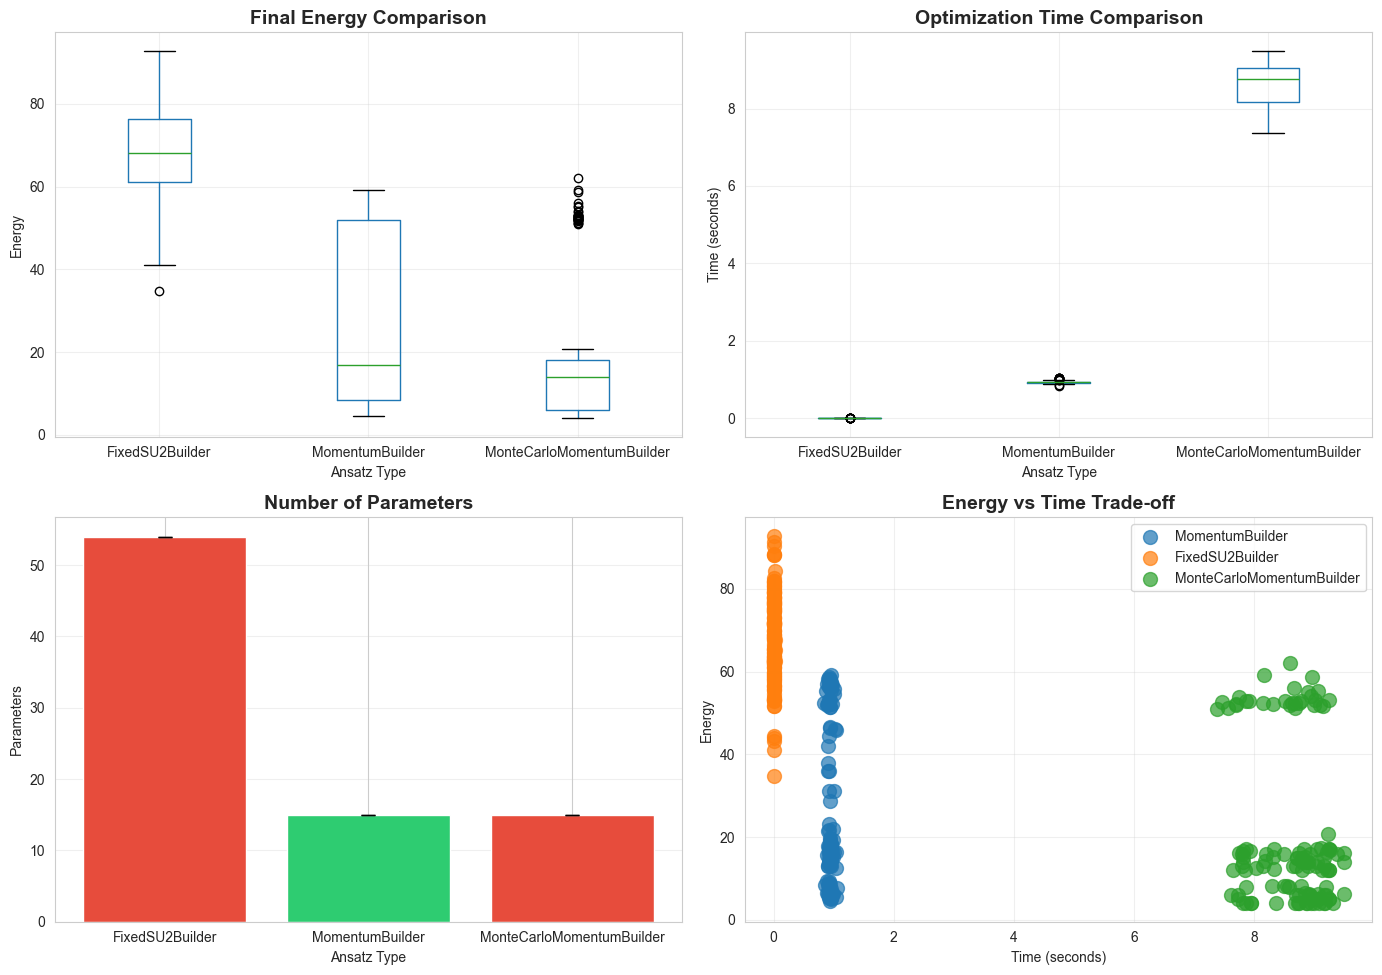

In [8]:
# Visualization 1: Main comparison plots
if len(df) > 0 and 'ansatz_type' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Energy comparison
    ax1 = axes[0, 0]
    df.boxplot(column='energy', by='ansatz_type', ax=ax1)
    ax1.set_title('Final Energy Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Ansatz Type')
    ax1.set_ylabel('Energy')
    ax1.grid(True, alpha=0.3)
    plt.suptitle('')
    
    # 2. Time comparison
    ax2 = axes[0, 1]
    df.boxplot(column='time', by='ansatz_type', ax=ax2)
    ax2.set_title('Optimization Time Comparison', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Ansatz Type')
    ax2.set_ylabel('Time (seconds)')
    ax2.grid(True, alpha=0.3)
    plt.suptitle('')
    
    # 3. Parameters comparison
    ax3 = axes[1, 0]
    param_means = df.groupby('ansatz_type')['params'].mean()
    param_stds = df.groupby('ansatz_type')['params'].std()
    x_pos = np.arange(len(param_means))
    ax3.bar(x_pos, param_means.values, yerr=param_stds.values, 
            color=['#e74c3c', '#2ecc71'], capsize=5)
    ax3.set_title('Number of Parameters', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Ansatz Type')
    ax3.set_ylabel('Parameters')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(param_means.index, rotation=0)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Energy vs Time scatter
    ax4 = axes[1, 1]
    for ansatz_type in df['ansatz_type'].unique():
        subset = df[df['ansatz_type'] == ansatz_type]
        ax4.scatter(subset['time'], subset['energy'], 
                   label=ansatz_type, alpha=0.7, s=100)
    ax4.set_title('Energy vs Time Trade-off', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Time (seconds)')
    ax4.set_ylabel('Energy')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ansatz_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


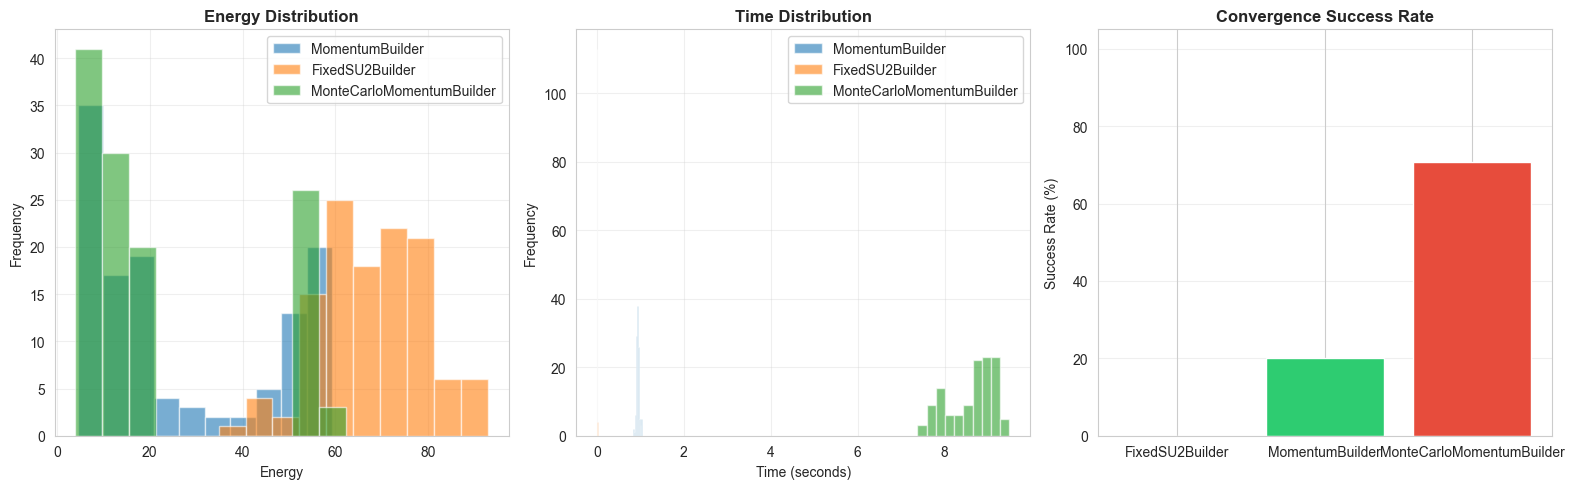

In [9]:
# Visualization 2: Detailed comparison plots
if len(df) > 0 and 'ansatz_type' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Energy distribution
    ax1 = axes[0]
    for ansatz_type in df['ansatz_type'].unique():
        subset = df[df['ansatz_type'] == ansatz_type]
        ax1.hist(subset['energy'], alpha=0.6, label=ansatz_type, bins=10)
    ax1.set_xlabel('Energy')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Energy Distribution', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Time distribution
    ax2 = axes[1]
    for ansatz_type in df['ansatz_type'].unique():
        subset = df[df['ansatz_type'] == ansatz_type]
        ax2.hist(subset['time'], alpha=0.6, label=ansatz_type, bins=10)
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Time Distribution', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Success rate
    ax3 = axes[2]
    success_rate = df.groupby('ansatz_type')['converged'].agg(['sum', 'count'])
    success_rate['rate'] = success_rate['sum'] / success_rate['count'] * 100
    x_pos = np.arange(len(success_rate))
    ax3.bar(x_pos, success_rate['rate'].values, color=['#e74c3c', '#2ecc71'])
    ax3.set_ylabel('Success Rate (%)')
    ax3.set_title('Convergence Success Rate', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(success_rate.index, rotation=0)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.savefig('ansatz_detailed_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()



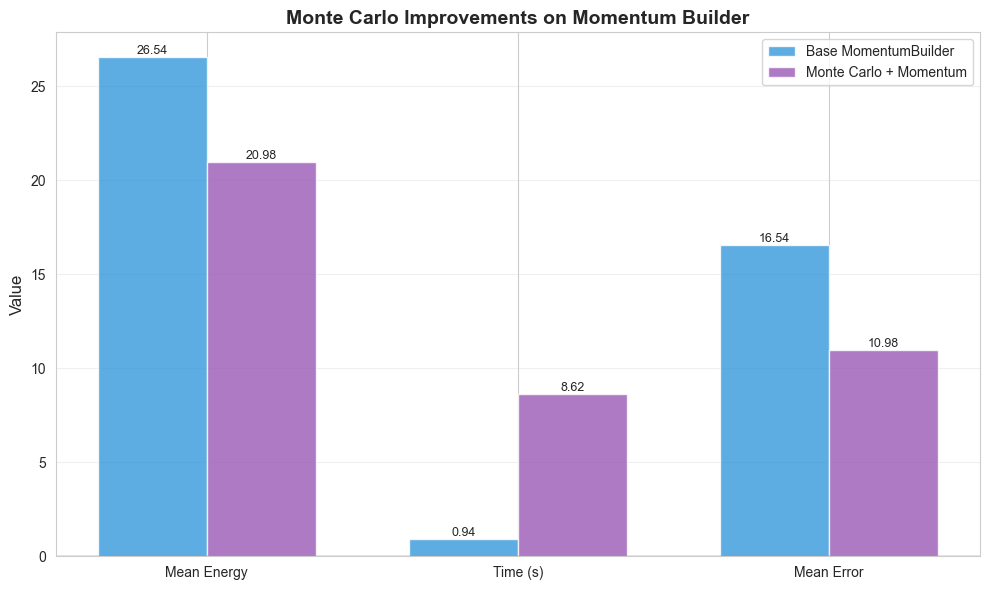


MONTE CARLO PERFORMANCE IMPROVEMENTS
Monte Carlo achieves lower average energy: 20.98 vs 26.54
Monte Carlo reduces average error by 33.6% (16.54 → 10.98)
Monte Carlo improves convergence success rate: 70.8% vs 20.0%
Energy Time Trade-off: Monte Carlo preprocessing takes 9.2x longer (8.62s vs 0.94s)


In [11]:
# Visualization 3: Performance metrics comparison (Momentum vs Monte Carlo + Momentum)
if len(df) > 0 and 'ansatz_type' in df.columns:
    momentum = df[df['ansatz_type'] == 'MomentumBuilder']
    mc_momentum = df[df['ansatz_type'] == 'MonteCarloMomentumBuilder']
    
    if len(momentum) > 0 and len(mc_momentum) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Compare Energy, Time, and Erro
        metrics = ['Mean Energy', 'Time (s)', 'Mean Error']
        
        momentum_vals = [
            momentum['energy'].mean(),
            momentum['time'].mean(),
            momentum['error'].mean()
        ]
        mc_vals = [
            mc_momentum['energy'].mean(),
            mc_momentum['time'].mean(),
            mc_momentum['error'].mean()
        ]
        
        x = np.arange(len(metrics))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, momentum_vals, width, label='Base MomentumBuilder', 
                      color='#3498db', alpha=0.8)
        bars2 = ax.bar(x + width/2, mc_vals, width, label='Monte Carlo + Momentum', 
                      color='#9b59b6', alpha=0.8)
        
        ax.set_ylabel('Value', fontsize=12)
        ax.set_title('Monte Carlo Improvements on Momentum Builder', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                # Place text below the bar if negative, above if positive
                y_pos = height if height >= 0 else height - (0.05 * abs(height))
                va_align = 'bottom' if height >= 0 else 'top'
                
                ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                        f'{height:.2f}',
                        ha='center', va=va_align, fontsize=9)
        
        ax.axhline(0, color='black', linewidth=1, alpha=0.5)
        
        plt.tight_layout()
        plt.savefig('mc_improvements_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print quantitative improvements
        print("\n" + "="*60)
        print("MONTE CARLO PERFORMANCE IMPROVEMENTS")
        print("="*60)
        
        # Energy
        e_mb = momentum['energy'].mean()
        e_mc = mc_momentum['energy'].mean()
        if e_mc < e_mb:
            print(f"Monte Carlo achieves lower average energy: {e_mc:.2f} vs {e_mb:.2f}")
        else:
            print(f"Base Momentum achieved lower energy: {e_mb:.2f} vs {e_mc:.2f}")
        # Error
        err_mb = momentum['error'].mean()
        err_mc = mc_momentum['error'].mean()
        if err_mc < err_mb:
            err_reduction = ((err_mb - err_mc) / max(err_mb, 1e-10)) * 100
            print(f"Monte Carlo reduces average error by {err_reduction:.1f}% ({err_mb:.2f} → {err_mc:.2f})")
        else:
            print(f"Monte Carlo increased average error ({err_mb:.2f} → {err_mc:.2f})")
            
        # Success Rate
        conv_mb = (momentum['converged'].sum() / len(momentum)) * 100
        conv_mc = (mc_momentum['converged'].sum() / len(mc_momentum)) * 100
        if conv_mc > conv_mb:
            print(f"Monte Carlo improves convergence success rate: {conv_mc:.1f}% vs {conv_mb:.1f}%")
        elif conv_mc == conv_mb:
            print(f"Success rate tied at {conv_mc:.1f}%")
        else:
            print(f"Monte Carlo lowered success rate: {conv_mc:.1f}% vs {conv_mb:.1f}%")

        # Time: Framed as a trade-off
        t_mb = momentum['time'].mean()
        t_mc = mc_momentum['time'].mean()
        t_ratio = t_mc / max(t_mb, 1e-10)
        print(f"Energy Time Trade-off: Monte Carlo preprocessing takes {t_ratio:.1f}x longer ({t_mc:.2f}s vs {t_mb:.2f}s)")